<a href="https://colab.research.google.com/github/juandguerrero/customer-churn-prediction/blob/main/churn_prediction2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data integration and understanding.

In [ ]:

# Load data

import pandas as pd

contract = pd.read_csv('contract.csv')
personal = pd.read_csv('personal.csv')
internet = pd.read_csv('internet.csv')
phone = pd.read_csv('phone.csv')


In [ ]:
# Merge the datasets

df = contract.merge(personal, on='customerID', how='left') \
             .merge(internet, on='customerID', how='left') \
             .merge(phone, on='customerID', how='left')

In [ ]:
# EDA

df.info()
df.describe(include='all')



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
count,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,5517,5517,5517,5517,5517,5517,5517,6361
unique,7043,77,5,3,2,4,NaN,6531,2,NaN,2,2,2,2,2,2,2,2,2,2
top,3186-AJIEK,2014-02-01,No,Month-to-month,Yes,Electronic check,NaN,,Male,NaN,No,No,Fiber optic,No,No,No,No,No,No,No
freq,1,366,5174,3875,4171,2365,NaN,11,3555,NaN,3641,4933,3096,3498,3088,3095,3473,2810,2785,3390
mean,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN,0.162147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN,0.368612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Data cleaning and preparation

In [ ]:
# 1. Correct data types

# A) Convert dates

# BeginDate and EndDate are as objects, they should be datetime.

df['BeginDate'] = pd.to_datetime(df['BeginDate'])

# EndDate has "No" when the customer has not cancelled
df['EndDate'] = df['EndDate'].replace('No', pd.NaT)
df['EndDate'] = pd.to_datetime(df['EndDate'])

#B) Convert TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')




In [ ]:
# 2. Handling missing values.

cols_internet = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

df[cols_internet] = df[cols_internet].fillna('No')

df['MultipleLines'] = df['MultipleLines'].fillna('No')

In [ ]:
# 3. Remove duplicates

df = df.drop_duplicates()


In [ ]:
# 4. Transform categorical variables (Encoding)

# There are many binary categorical columns (Yes/No).

# A) Map binary columns
binary_cols = [
    'PaperlessBilling', 'Partner', 'Dependents',
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies',
    'MultipleLines'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# B) Gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# C) One-Hot Encoding for variables with more than 2 categories
df = pd.get_dummies(
    df,
    columns=['Type', 'PaymentMethod', 'InternetService'],
    drop_first=True
)




# 3. Detailed EDA



In [ ]:
# 1. Create the target variable (Churn).

df['Churn'] = df['EndDate'].notna().astype(int)

In [ ]:
# 2. Analyze the balance of the target variable

df['Churn'].value_counts(normalize=True)


,proportion
Churn,
0,0.73463
1,0.26537


**Interpretation**

The dataset shows a moderate imbalance:

The majority class (active customers) accounts for approximately 3/4 of the total.

The minority class (customers who churn) accounts for about 1/4 of the total.

This level of imbalance is not extreme, but it is significant enough to:

Avoid using accuracy as the main metric alone.

Prioritize metrics that consider performance on the minority class.


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

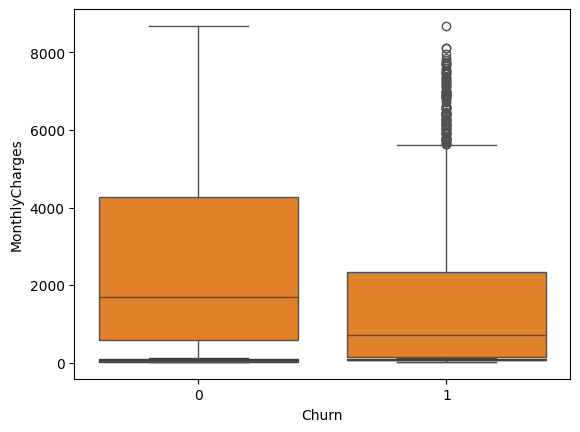

In [ ]:
# 3. Analysis of numerical variables

import seaborn as sns

# A) MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

# B) TotalCharges vs Churn
sns.boxplot(x='Churn', y='TotalCharges', data=df)


<Axes: xlabel='Tenure', ylabel='Count'>

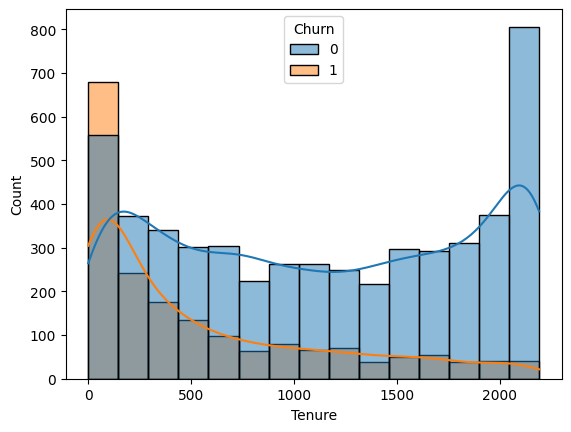

In [ ]:
# 4. Key feature: Customer tenure (Tenure)

reference_date = pd.to_datetime('2020-02-01')

df['Tenure'] = (
    (df['EndDate'].fillna(reference_date) - df['BeginDate'])
    .dt.days
)

sns.histplot(data=df, x='Tenure', hue='Churn', kde=True)


In [ ]:

# 5. Relevant categorical variables

# A) Contract type (One year)
pd.crosstab(df['Type_One year'], df['Churn'], normalize='index')

# Contract type (Two year)
pd.crosstab(df['Type_Two year'], df['Churn'], normalize='index')

# B) Payment method (Electronic check)
pd.crosstab(df['PaymentMethod_Electronic check'], df['Churn'], normalize='index')

# C) Additional services (TechSupport)
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index')


Churn,0,1
TechSupport,,
0,0.688138,0.311862
1,0.848337,0.151663


In [ ]:
# 6. SeniorCitizen

pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')



Churn,0,1
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


<Axes: >

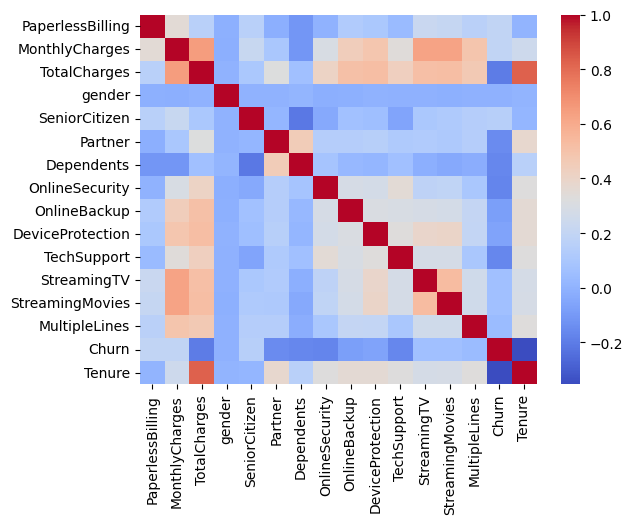

In [ ]:
# 7. Correlation among numerical variables

sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')




# 3.1 Interpret the charts with a business and modeling mindset



## 1. Boxplot: TotalCharges vs Churn

**What the chart shows:**

- Churn = 1 customers have a much lower median in TotalCharges.
- Churn = 0 customers have much higher values and more dispersion.
- There are high outliers in churn = 1, but the main concentration is at the lower end.

**Correct interpretation:**

- This confirms something very important:
  - Most customers who churn do so relatively early.
  - Because TotalCharges is cumulative.

**Business insight:**

- Churn mainly occurs among new customers.
- The problem is not dissatisfied long-term customers.
- It’s related to onboarding / the first months.


## 2. Histogram: Tenure vs Churn

**Observations:**

- In the first days/months, there is a high concentration of churn.
- As Tenure increases, the proportion of churn decreases sharply.
- Customers with long tenure almost never churn.

**Strong conclusion:**

- Tenure is likely one of the most predictive variables for the model.

**Technical perspective:**

- Expect a strong negative correlation with Churn.
- It will have high importance in Random Forest / Gradient Boosting models.

**Business perspective:**

- Risk is high in the early stage.
- Strategy: retention campaigns during the first months.



## 3. Correlation Heatmap

**Key observations:**

- **A) Tenure vs Churn → strong negative correlation**  
  This is consistent with the histogram.

- **B) MonthlyCharges vs Churn → moderate positive correlation**  
  Customers with higher monthly payments tend to churn more.

- **C) Type_Two year → strong negative correlation**  
  Long-term contracts significantly reduce churn.

- **D) PaymentMethod_Electronic check → positive correlation**  
  This payment method is associated with higher churn.

- **E) SeniorCitizen → positive correlation**  
  The numbers confirm this:  
  - Senior = 0 → 23.6% churn  
  - Senior = 1 → 41.6% churn  

  This is a substantial difference.




## 4. Additional Services: TechSupport

**Insight:**  
Added services lead to higher customer retention.


# 4. Feature Engineering

In [ ]:
# 1. Feature: Total number of services

service_cols = [
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

df['TotalServices'] = df[service_cols].sum(axis=1)

# Hypothesis: More services → lower churn

# 2. Group Tenure into stages

df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[0, 180, 365, 730, 5000],
    labels=['0-6m', '6-12m', '1-2y', '2y+']
)

# This helps linear models and business interpretation

# 3. Feature: New customer (Early Risk)

df['EarlyStage'] = (df['Tenure'] < 180).astype(int)

# Because we already saw that churn is concentrated here

# 4. Interaction: High price + monthly contract

df['HighMonthly'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

df['RiskProfile'] = df['HighMonthly'] * (df['Type_One year'] == 0) * (df['Type_Two year'] == 0)

# This captures:
# - High payment
# - No long-term contract
# - Classic churn profile



# 5. Training and evaluation of the model



In [ ]:
# 1. Prepare data for modeling

X = df.drop(columns=['customerID', 'BeginDate', 'EndDate', 'Churn'])
y = df['Churn']

In [ ]:
# 2. Train / Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important because of the imbalance
)

In [ ]:
# 3. Scaling (only for linear models)

from sklearn.preprocessing import StandardScaler

# Fill NaN with the median of the training set
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

# Select numeric columns
X_train_num = X_train.select_dtypes(include=['int64', 'float64', 'uint8'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64', 'uint8'])

scaler = StandardScaler()

# Fit the scaler on the training data and transform
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)



In [ ]:
# 4. Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# Train the model
log_reg.fit(X_train_scaled, y_train)

# Evaluation

from sklearn.metrics import classification_report

# Predict class labels
y_pred = log_reg.predict(X_test_scaled)

# Predict probabilities for the positive class
y_proba = log_reg.predict_proba(X_test_scaled)[:,1]

# Print classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [ ]:
# 5. Model 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

# Select numeric columns
X_train = X_train.select_dtypes(include=['int64', 'float64', 'uint8'])
X_test = X_test.select_dtypes(include=['int64', 'float64', 'uint8'])

# Train the model
rf.fit(X_train, y_train)

# Evaluation

# Predict class labels
y_pred_rf = rf.predict(X_test)

# Predict probabilities for the positive class
y_proba_rf = rf.predict_proba(X_test)[:,1]

# Print classification report
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1035
           1       0.70      0.50      0.58       374

    accuracy                           0.81      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
# 6. Model 3: Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

# Train the model
gb.fit(X_train, y_train)

# Evaluation

# Predict class labels
y_pred_gb = gb.predict(X_test)

# Predict probabilities for the positive class
y_proba_gb = gb.predict_proba(X_test)[:,1]

# Print classification report
print(classification_report(y_test, y_pred_gb))


              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1035
           1       0.78      0.57      0.66       374

    accuracy                           0.84      1409
   macro avg       0.82      0.76      0.78      1409
weighted avg       0.84      0.84      0.84      1409



# 6. Business Interpretation and Recommendations

## Variables with the Greatest Impact on Churn

Based on the EDA and the model (Gradient Boosting, ROC-AUC = 0.89), the most important variables are:

1. **Tenure**  
   New customers churn much more.  
   Churn mainly occurs in the first months.

2. **Contract Type**  
   Monthly contract → higher churn.  
   1-year and 2-year contracts → significantly reduce churn.

3. **MonthlyCharges**  
   High charges are associated with higher churn.

4. **Additional Services** (TechSupport, Security, etc.)  
   More services → lower churn.  
   They act as a retention factor.

5. **SeniorCitizen and Electronic Check**  
   Show higher churn rates.

## Actionable Strategies to Reduce Churn

- **Early Retention Program**  
  Offer discounts or benefits to customers with less than 6 months.

- **Encourage Long-Term Contracts**  
  Promotions to migrate from monthly to 1–2 year contracts.

- **Promote Service Bundles**  
  Offer TechSupport or additional services at a discount.

- **Targeted Segmentation (Senior Customers)**  
  Provide personalized attention or simplified support.

## Conclusion

Churn at Interconnect is mainly associated with low tenure and monthly contracts.  
The predictive model allows identifying at-risk customers and applying promotions strategically, optimizing costs and increasing retention.